In [1]:
!git clone -b test120 https://github.com/cho-colette/Pelagia1.git

Cloning into 'Pelagia1'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 106 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 40.00 KiB | 4.00 MiB/s, done.
Resolving deltas: 100% (55/55), done.


In [1]:
%cd /content/Pelagia1
!pwd
!git branch --show-current

/content/Pelagia1
/content/Pelagia1
test120


In [2]:
!pip install -r requirements.txt

In [3]:
import sys

src_path = "/content/Pelagia1/src"
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(sys.path[0])

/content/Pelagia1/src


In [4]:
from utils import SignalConfig
from generate_signals import generate_dataset
from extract_features import build_feature_table
from train_classifier import train_classifier
from train_anomaly_model import train_anomaly_model
from streaming_update import run_streaming_update_demo
from plot_branches import plot_decision_tree_figure, plot_confusion_matrix_heatmap

In [5]:
config = SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)
config

SignalConfig(duration_s=120.0, sample_rate_hz=10.0, random_seed=42)

In [6]:
print("1. Generating synthetic signals...")
df = generate_dataset(config=config)
print(df.shape)
df.head()

1. Generating synthetic signals...
(576000, 13)


,time_s,petal_1,petal_2,petal_3,voltage_v,current_a,power_w,energy_j,temperature_c,fold_state,state_id,state_label,case_id
0,0.0,0.009429,0.042330,-0.052062,10.211764,1.076476,10.992715,1.099272,20.562371,0.0,0,normal_harvesting,state_0_sample_000
1,0.1,0.035531,0.052066,-0.053330,10.084936,1.210248,12.205271,2.319799,20.718594,0.0,0,normal_harvesting,state_0_sample_000
2,0.2,0.092859,0.100234,-0.011027,10.606972,1.149566,12.193409,3.539140,20.700546,0.0,0,normal_harvesting,state_0_sample_000
3,0.3,0.123780,0.122659,0.044195,10.394243,1.216094,12.640380,4.803178,20.578021,0.0,0,normal_harvesting,state_0_sample_000
4,0.4,0.142810,0.140046,0.100083,10.356292,1.281293,13.269442,6.130122,20.498533,0.0,0,normal_harvesting,state_0_sample_000


In [7]:
print("2. Extracting features...")
features = build_feature_table(sample_rate_hz=config.sample_rate_hz)
print(features.shape)
features.head()

2. Extracting features...
(480, 37)


,case_id,state_id,state_label,amp_petal_1,amp_petal_2,amp_petal_3,mean_petal_1,mean_petal_2,mean_petal_3,std_petal_1,...,max_power_w,mean_dpower,max_abs_dpower,rolling_power_mean_final,rolling_power_std_final,mean_temperature_c,max_temperature_c,mean_dtemp,energy_final_j,fold_state_final
0,state_0_sample_000,0,normal_harvesting,0.265240,0.248275,0.266663,0.015991,-0.004484,0.006199,0.137349,...,18.220955,0.029952,28.830700,13.621520,1.226602,20.958468,21.785827,0.010743,1620.997000,0.0
1,state_0_sample_001,0,normal_harvesting,0.270572,0.267575,0.290659,0.002309,0.004058,0.005495,0.137205,...,18.679017,0.047900,26.667541,15.047591,1.361064,21.658262,22.451357,0.008824,1768.818643,0.0
2,state_0_sample_002,0,normal_harvesting,0.299251,0.298090,0.299572,0.005972,0.003990,-0.006625,0.150760,...,19.629498,0.003771,26.140203,14.009174,1.772419,21.757725,22.549592,0.012509,1733.770582,0.0
3,state_0_sample_003,0,normal_harvesting,0.252505,0.241803,0.272039,0.016573,0.003784,0.007045,0.125953,...,17.809751,0.046560,20.900622,14.383642,1.115314,21.236764,22.096424,0.005860,1621.722749,0.0
4,state_0_sample_004,0,normal_harvesting,0.235345,0.230112,0.245595,0.000039,0.006169,0.005884,0.125614,...,17.850591,0.047815,27.033392,13.659335,1.431119,21.260169,21.939424,0.006210,1663.393894,0.0


In [8]:
print("3. Training classifier...")
classifier_outputs = train_classifier()
print(classifier_outputs["metrics"])
print(classifier_outputs["confusion_df"])

3. Training classifier...
{'accuracy': 0.9666666666666667, 'n_train': 360, 'n_test': 120, 'n_features': 25, 'classes': ['adaptive_operation', 'anomaly_inspection', 'normal_harvesting', 'protective_mode']}
                    adaptive_operation  anomaly_inspection  normal_harvesting  \
adaptive_operation                  29                   0                  1   
anomaly_inspection                   2                  28                  0   
normal_harvesting                    0                   1                 29   
protective_mode                      0                   0                  0   

                    protective_mode  
adaptive_operation                0  
anomaly_inspection                0  
normal_harvesting                 0  
protective_mode                  30  


In [9]:
print("4. Training anomaly model...")
anomaly_outputs = train_anomaly_model()
print(anomaly_outputs)

4. Training anomaly model...
{'model': IsolationForest(contamination=0.08, n_estimators=300, random_state=42), 'scaler': StandardScaler(), 'results':                 case_id        state_label  anomaly_score  anomaly_flag  \
0    state_0_sample_000  normal_harvesting       0.074434             1   
1    state_0_sample_001  normal_harvesting       0.101361             1   
2    state_0_sample_002  normal_harvesting       0.020357             1   
3    state_0_sample_003  normal_harvesting       0.112106             1   
4    state_0_sample_004  normal_harvesting       0.094196             1   
..                  ...                ...            ...           ...   
475  state_3_sample_115    protective_mode      -0.143995            -1   
476  state_3_sample_116    protective_mode      -0.143565            -1   
477  state_3_sample_117    protective_mode      -0.138127            -1   
478  state_3_sample_118    protective_mode      -0.152431            -1   
479  state_3_sample_119  

In [10]:
print("5. Running streaming update demo...")
stream_outputs = run_streaming_update_demo()
print(stream_outputs)

5. Running streaming update demo...
{'model': SGDClassifier(loss='log_loss', max_iter=1, random_state=42, tol=None), 'metrics_df':     samples_seen  batch_end_index  running_accuracy
0              8                8          0.125000
1             16               16          0.250000
2             24               24          0.125000
3             32               32          0.156250
4             40               40          0.325000
5             48               48          0.333333
6             56               56          0.339286
7             64               64          0.390625
8             72               72          0.416667
9             80               80          0.200000
10            88               88          0.329545
11            96               96          0.291667
12           104              104          0.336538
13           112              112          0.294643
14           120              120          0.358333
15           128              128    

In [11]:
print("6. Plotting figures...")
out_tree = plot_decision_tree_figure(fontsize=32)
out_cm = plot_confusion_matrix_heatmap()

print("Decision tree:", out_tree)
print("Confusion matrix:", out_cm)

6. Plotting figures...
Decision tree: figures/pelagia_decision_tree.png
Confusion matrix: figures/pelagia_confusion_matrix.png


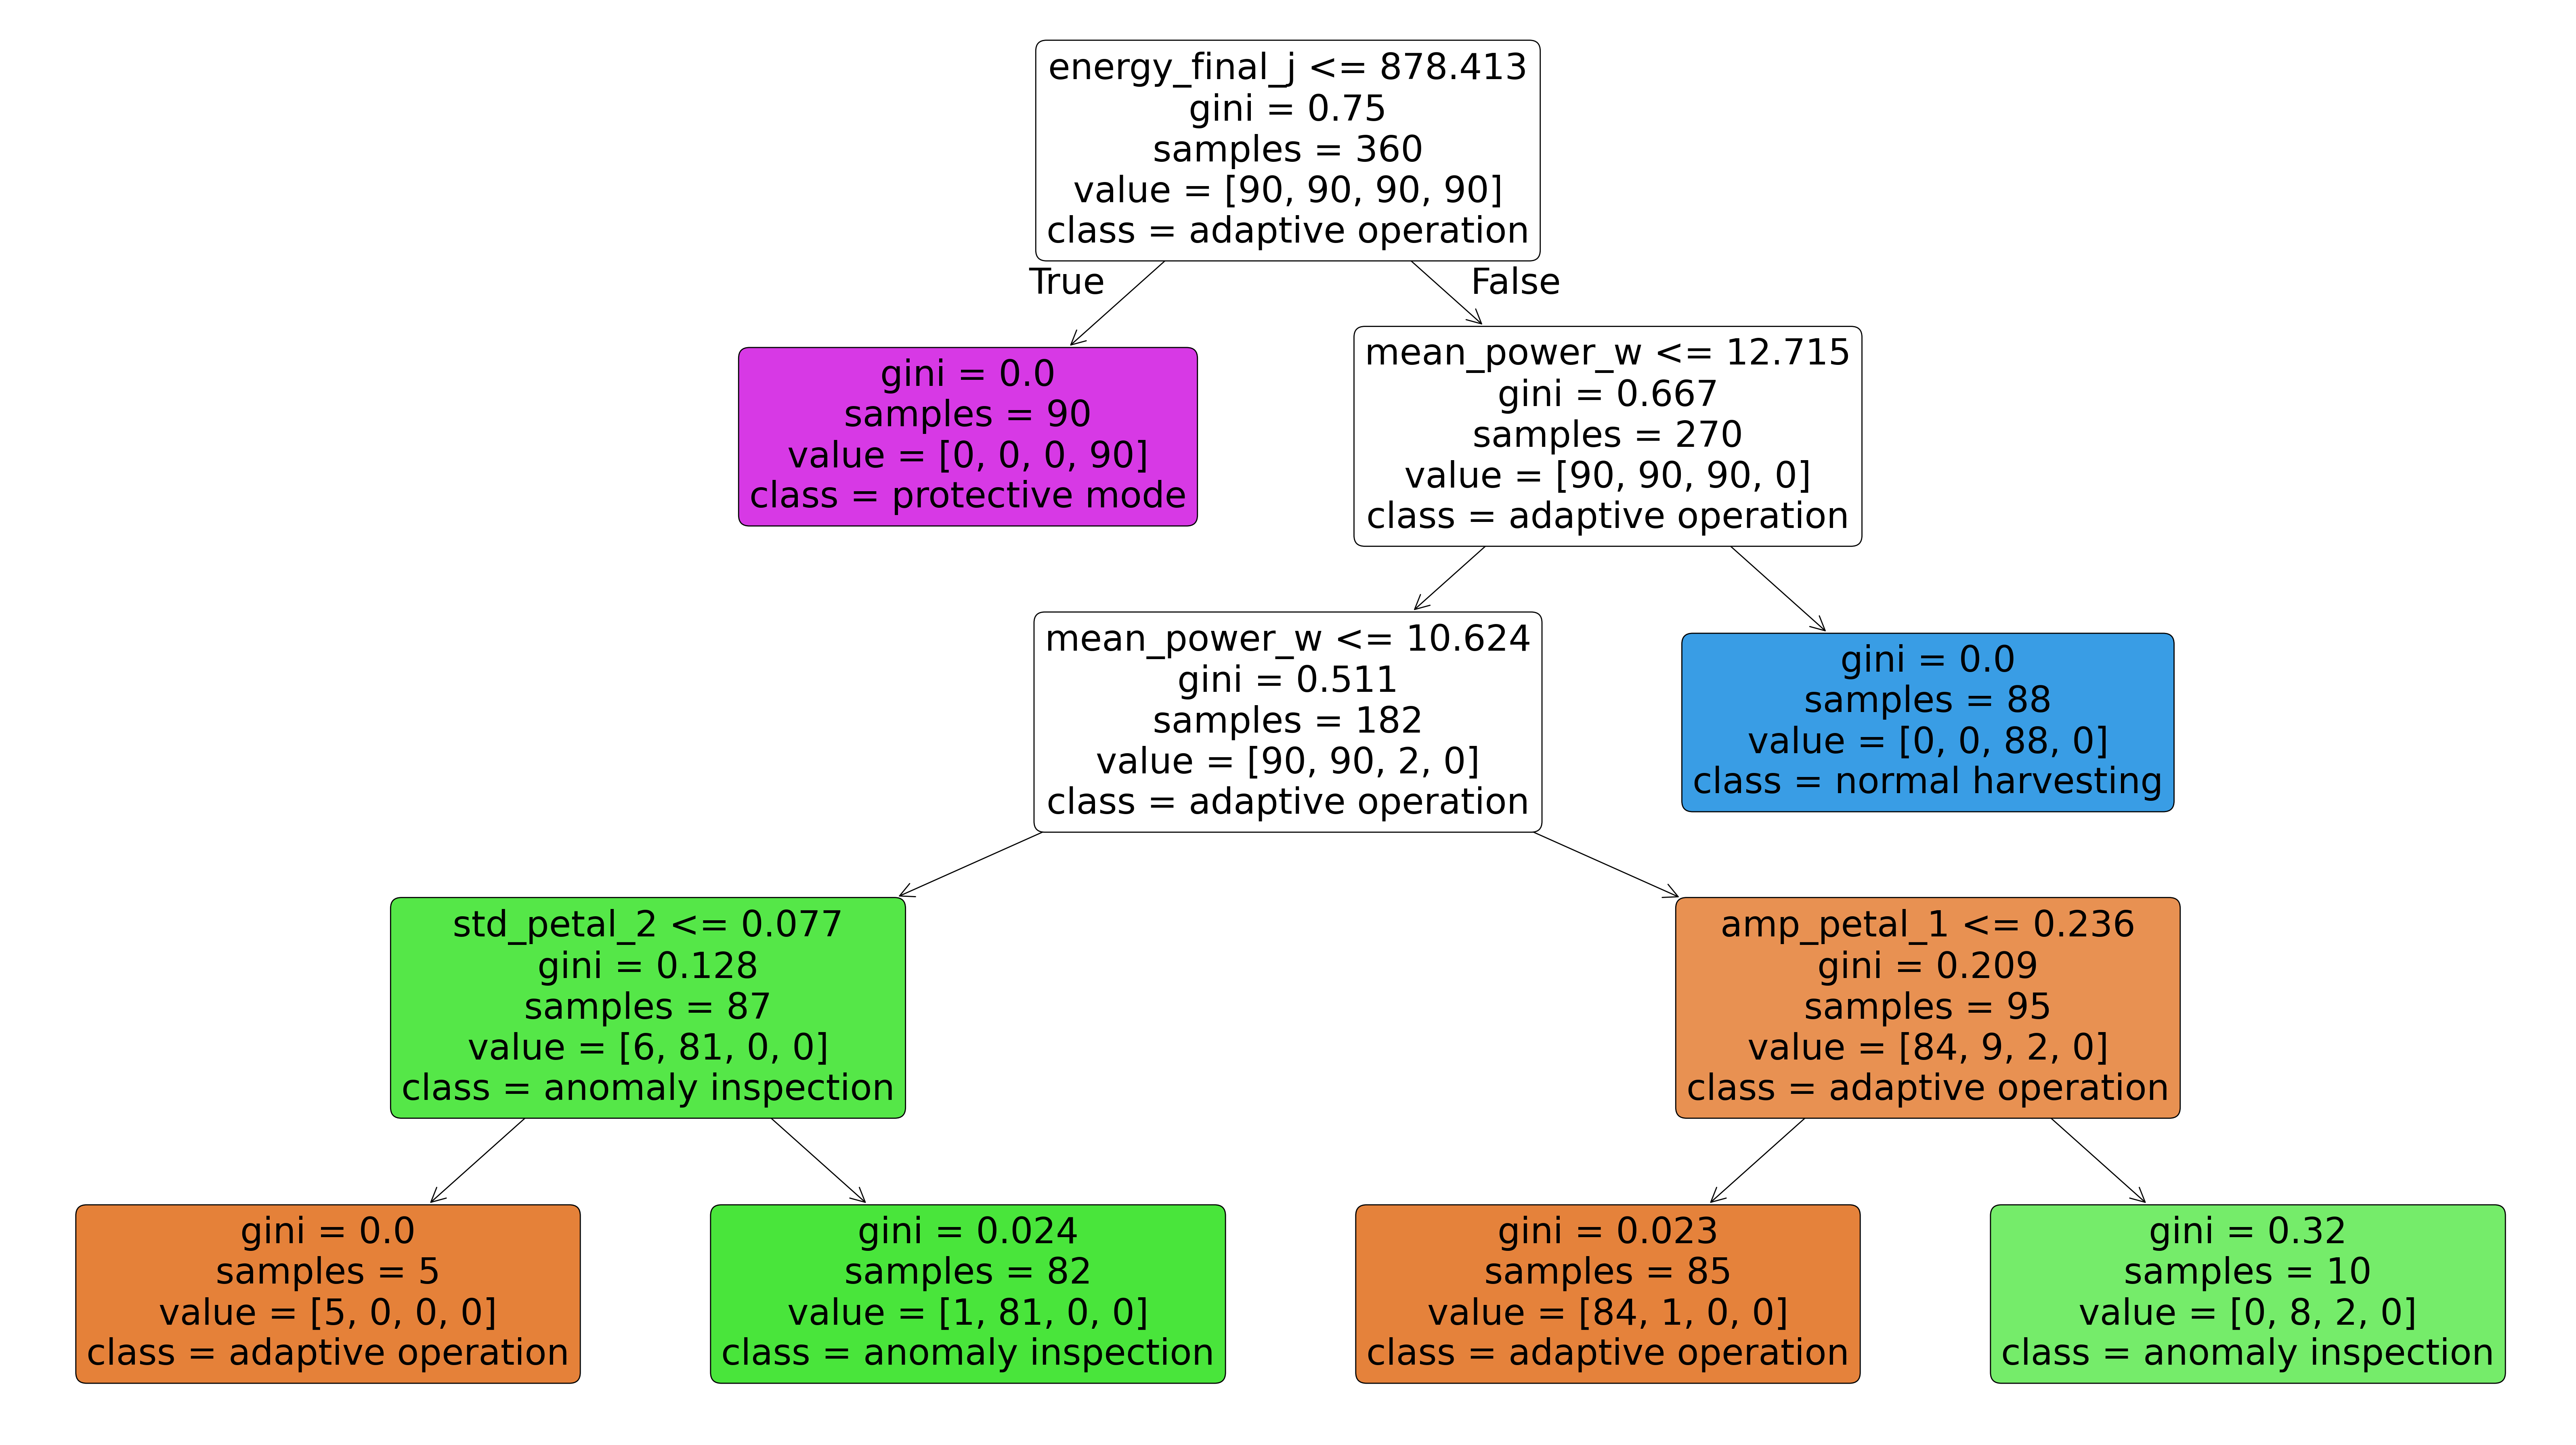

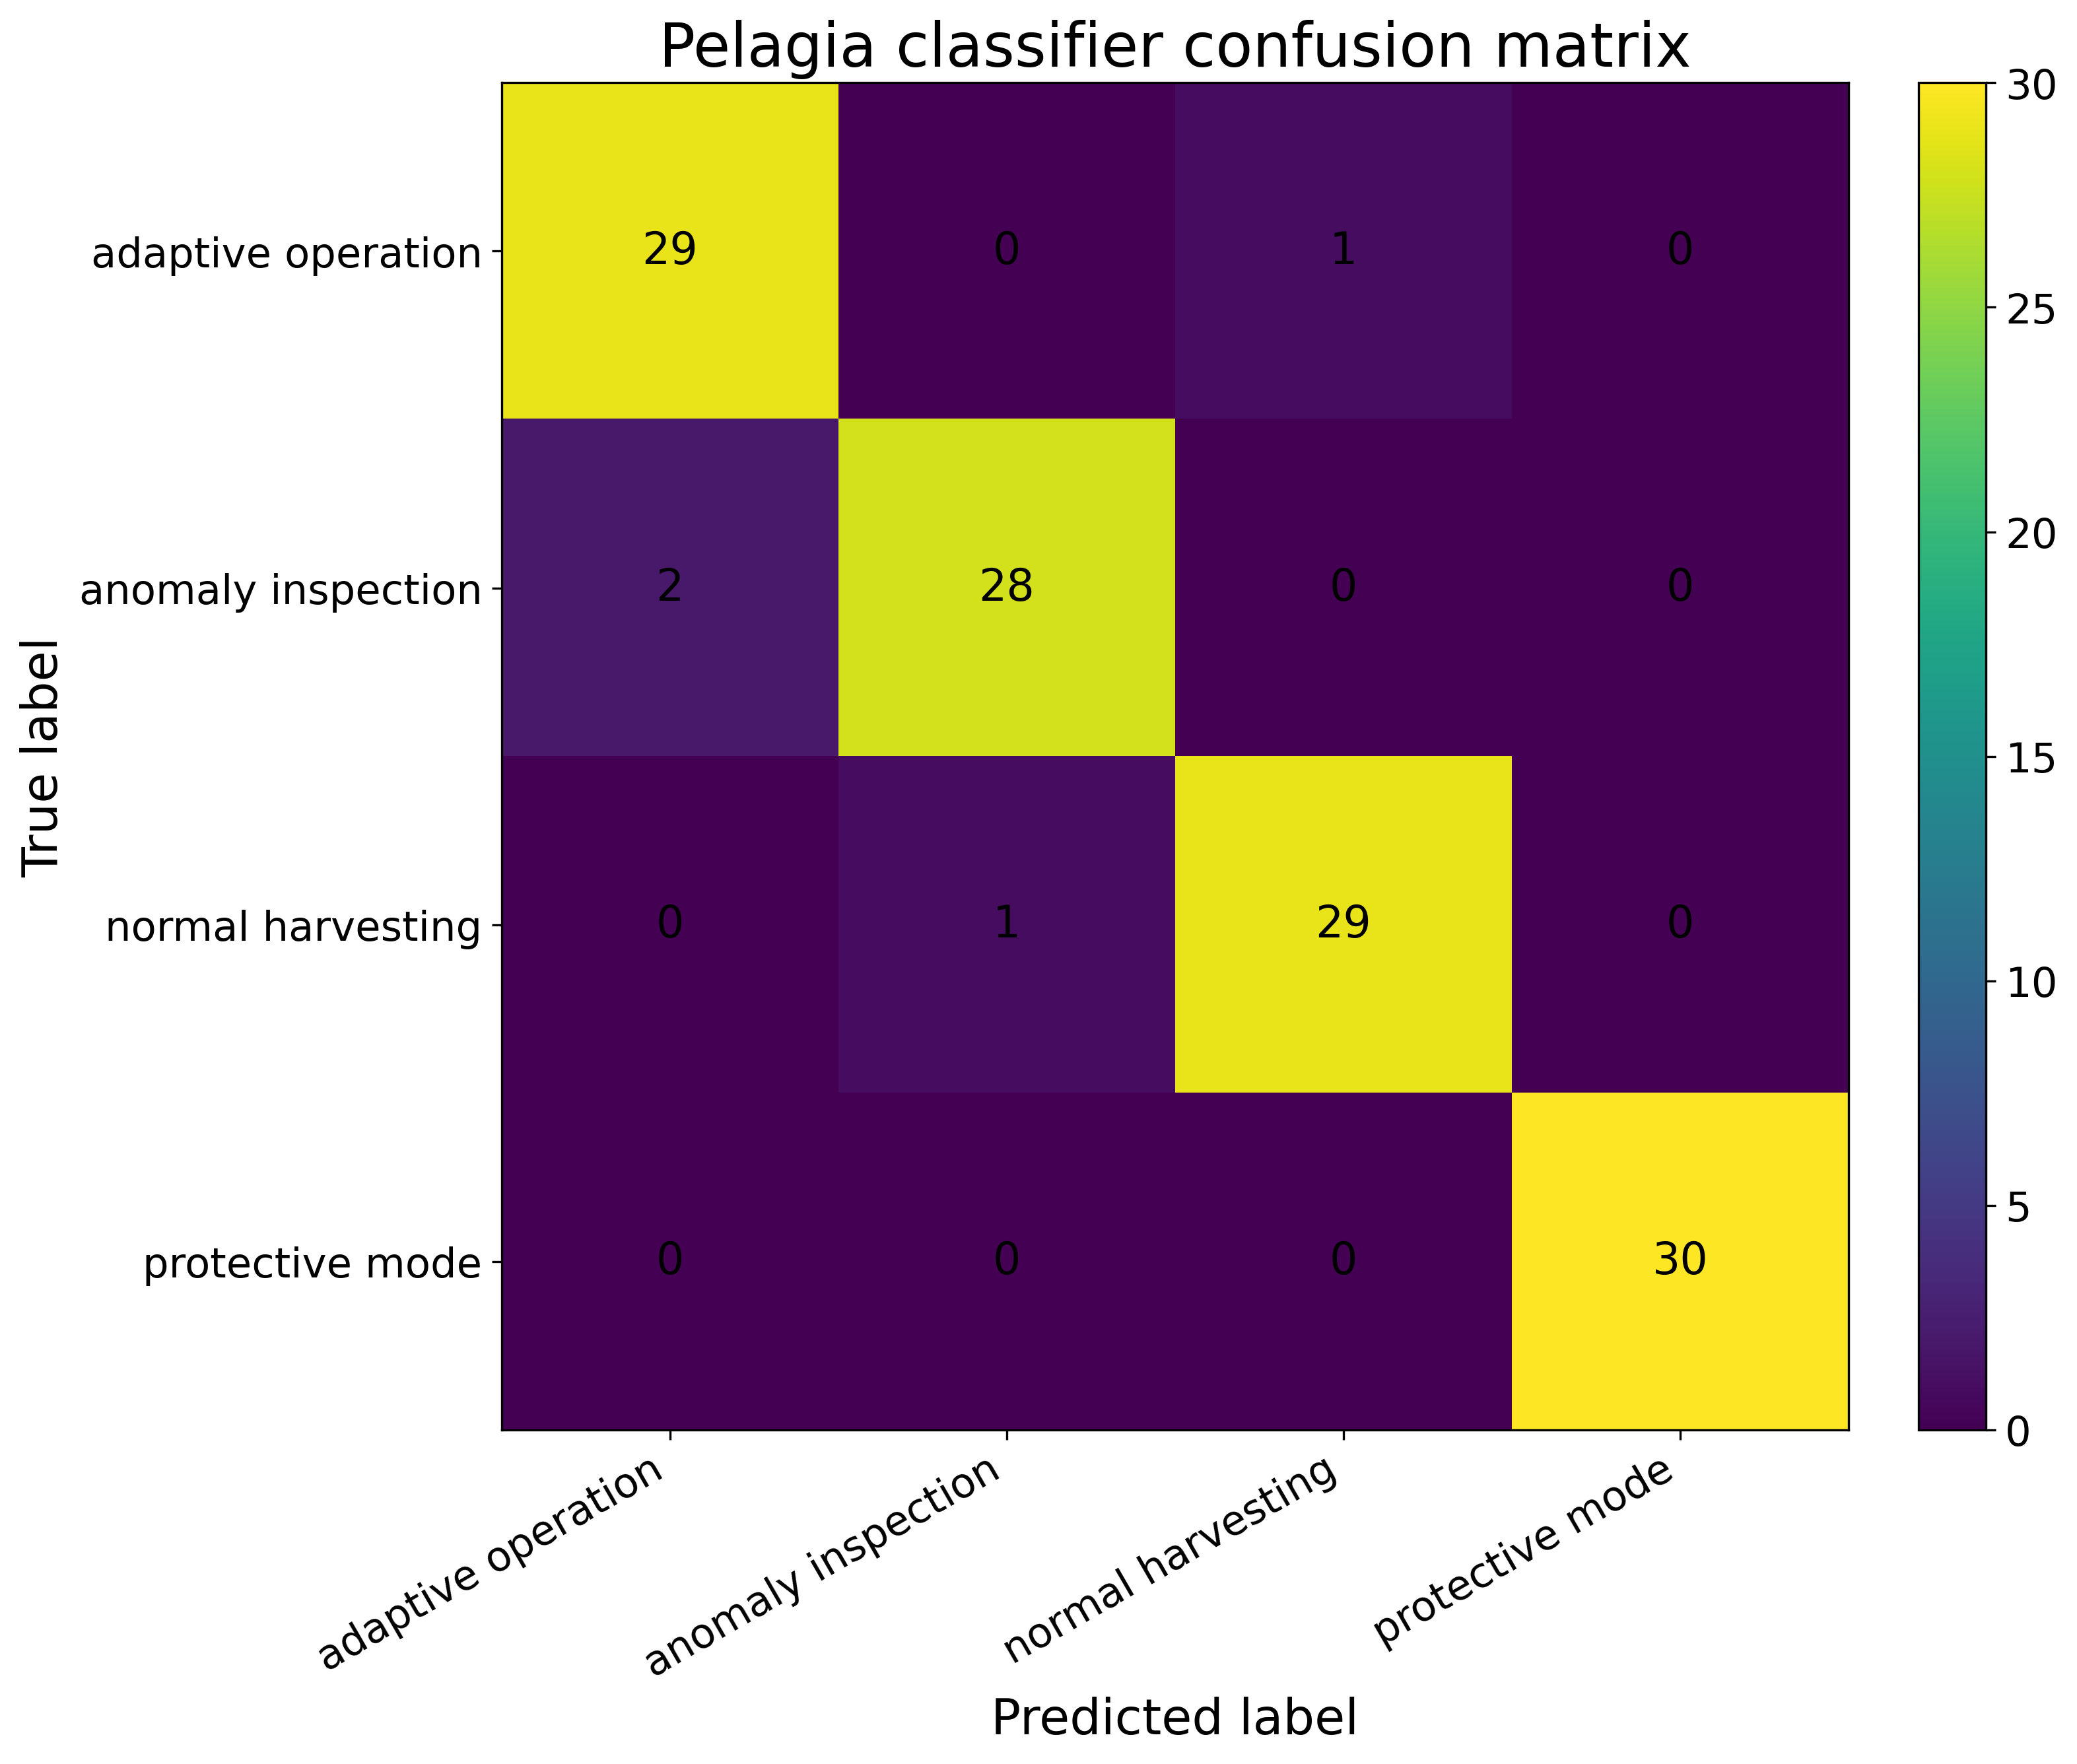

In [12]:
from IPython.display import Image, display

display(Image(filename=str(out_tree)))
display(Image(filename=str(out_cm)))

In [13]:
import shutil
from pathlib import Path
from google.colab import files

source_dir = Path("/content/Pelagia1/figures")
bundle_dir = Path("/content/pelagia_two_figures")

if bundle_dir.exists():
    shutil.rmtree(bundle_dir)
bundle_dir.mkdir(parents=True, exist_ok=True)

for name in ["pelagia_decision_tree.png", "pelagia_confusion_matrix.png"]:
    src = source_dir / name
    if src.exists():
        shutil.copy(src, bundle_dir / name)
        print("Added:", name)
    else:
        print("Missing:", name)

zip_path = shutil.make_archive("/content/pelagia_two_figures", "zip", bundle_dir)
print("Created:", zip_path)
files.download(zip_path)

Added: pelagia_decision_tree.png
Added: pelagia_confusion_matrix.png
Created: /content/pelagia_two_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved to: figures/pelagia_decision_tree.png


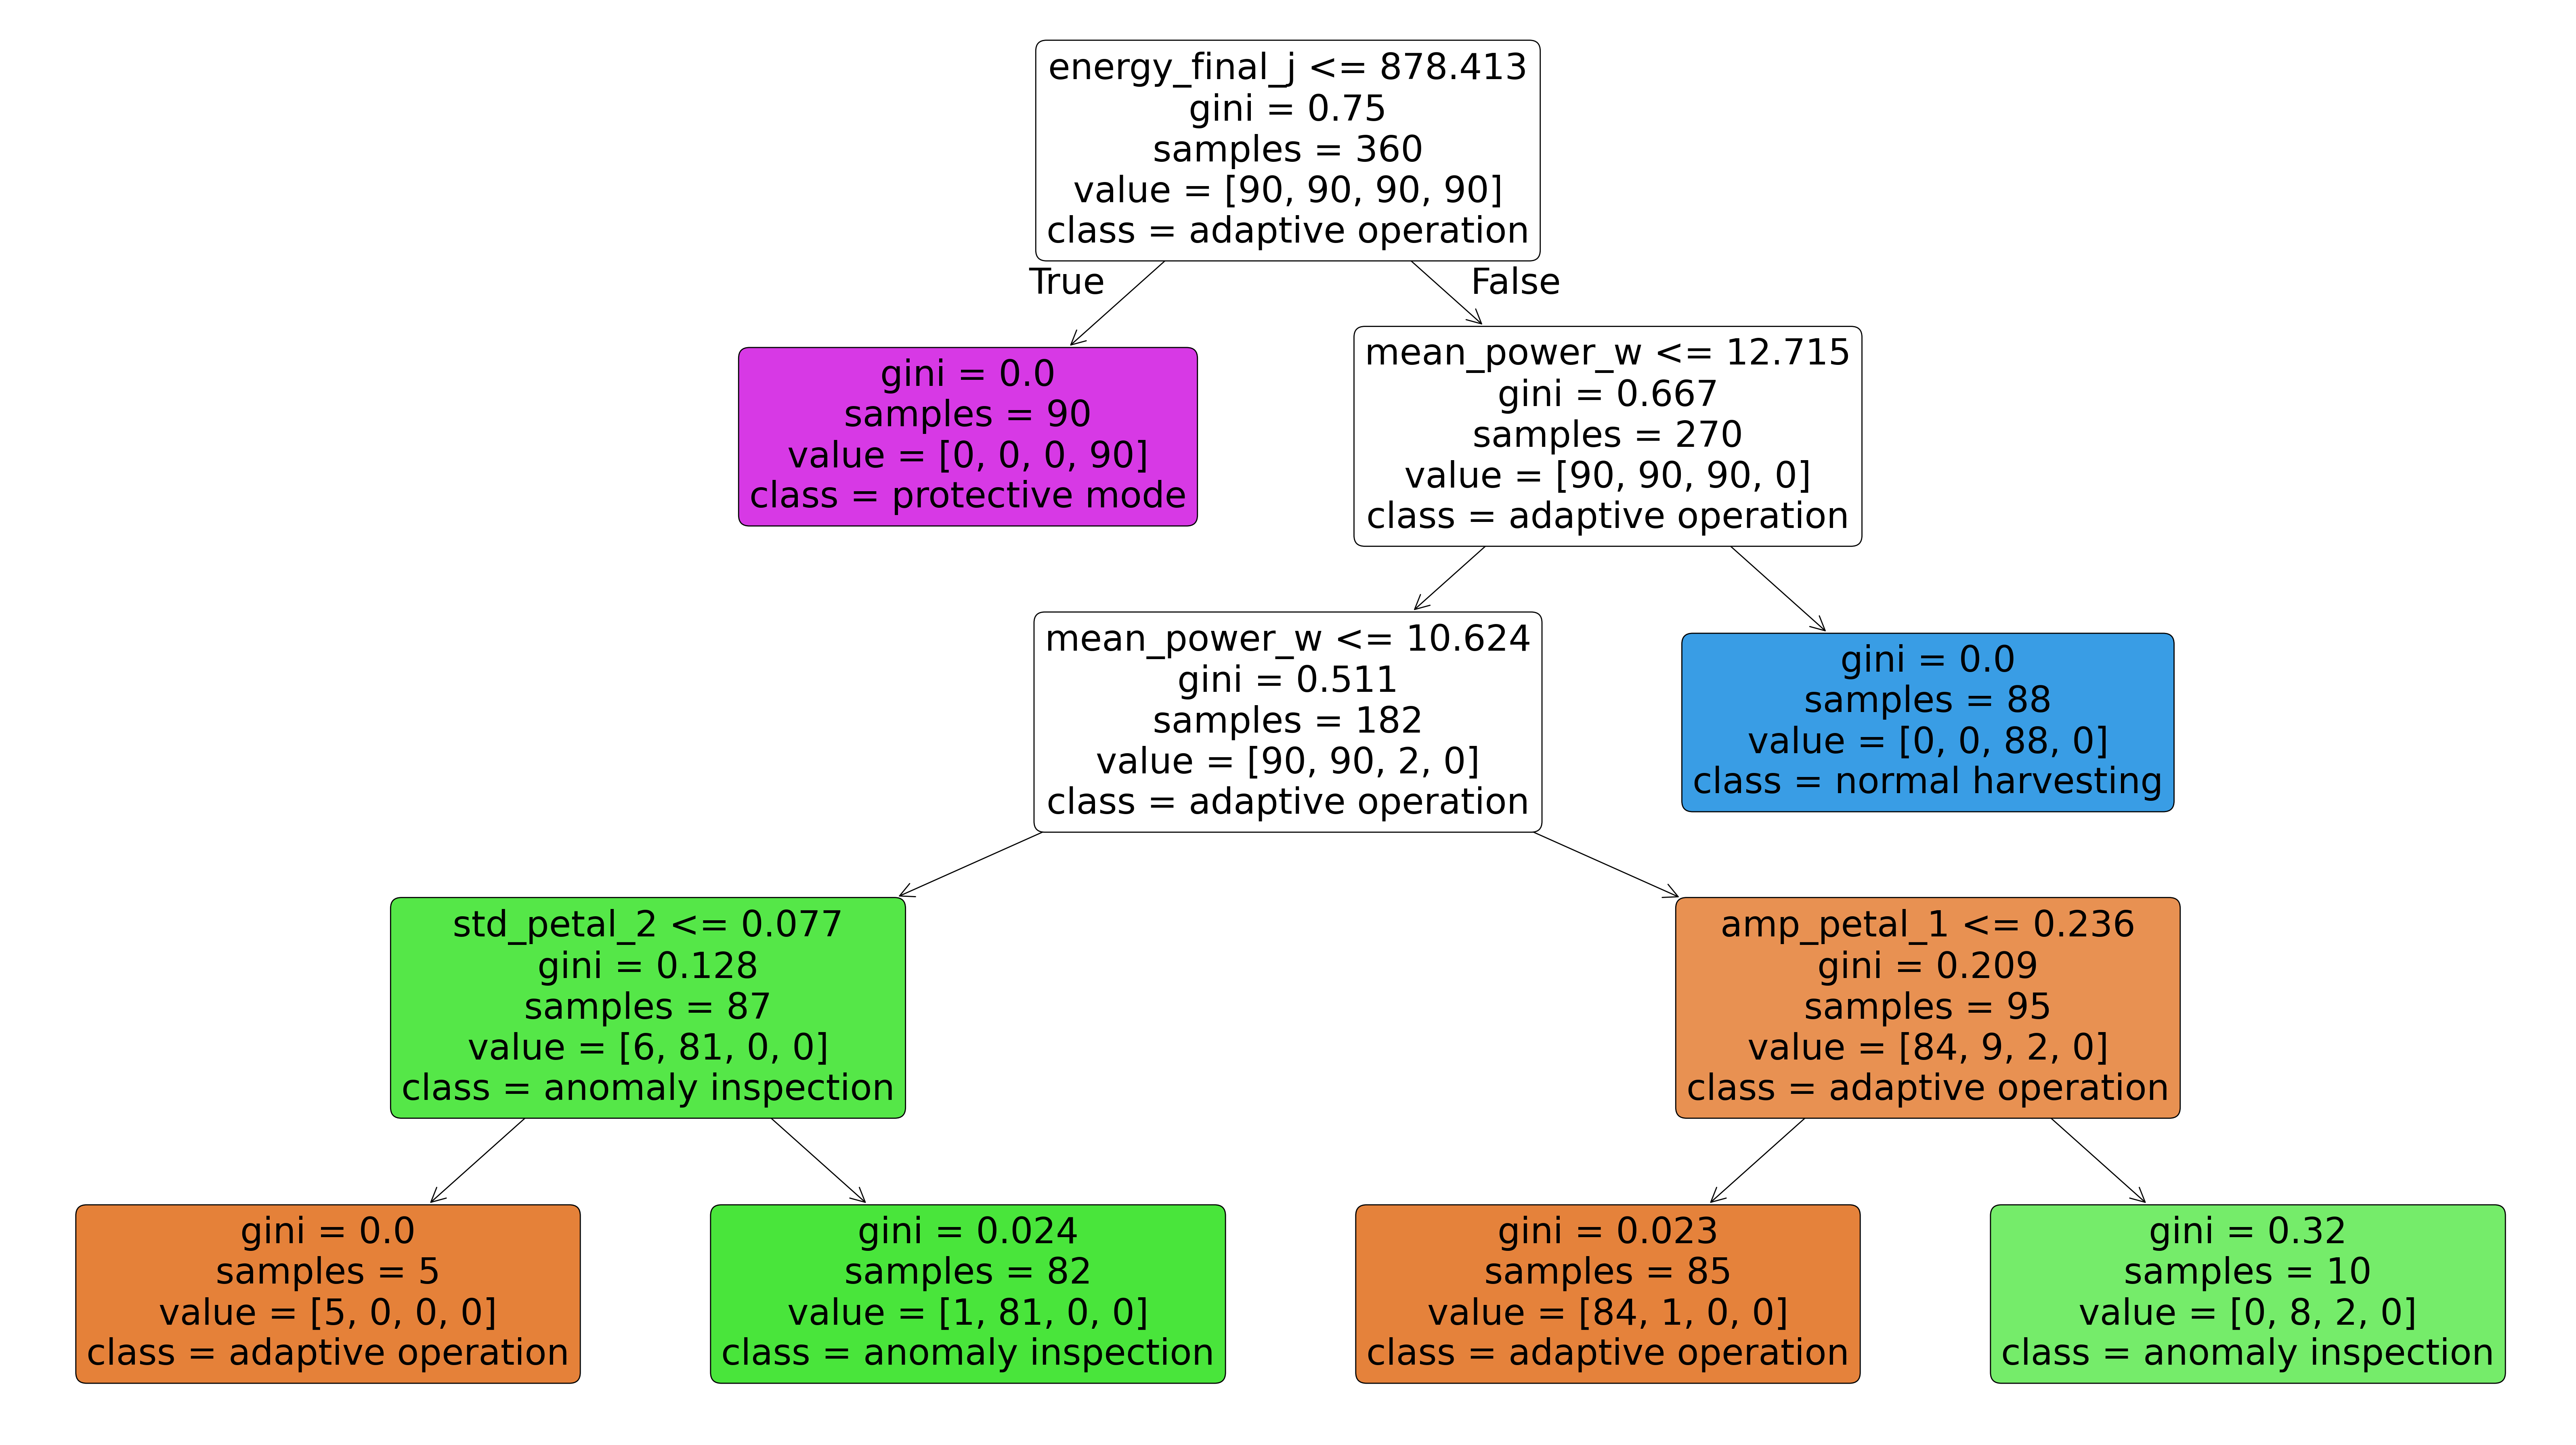

In [16]:
from plot_branches import plot_decision_tree_figure
from IPython.display import Image, display

out_tree = plot_decision_tree_figure(fontsize=32)
print("Saved to:", out_tree)

display(Image(filename=str(out_tree)))